In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")

# Built-in datasets
iris  = sns.load_dataset('iris')
tips  = sns.load_dataset('tips')
flights = sns.load_dataset('flights')

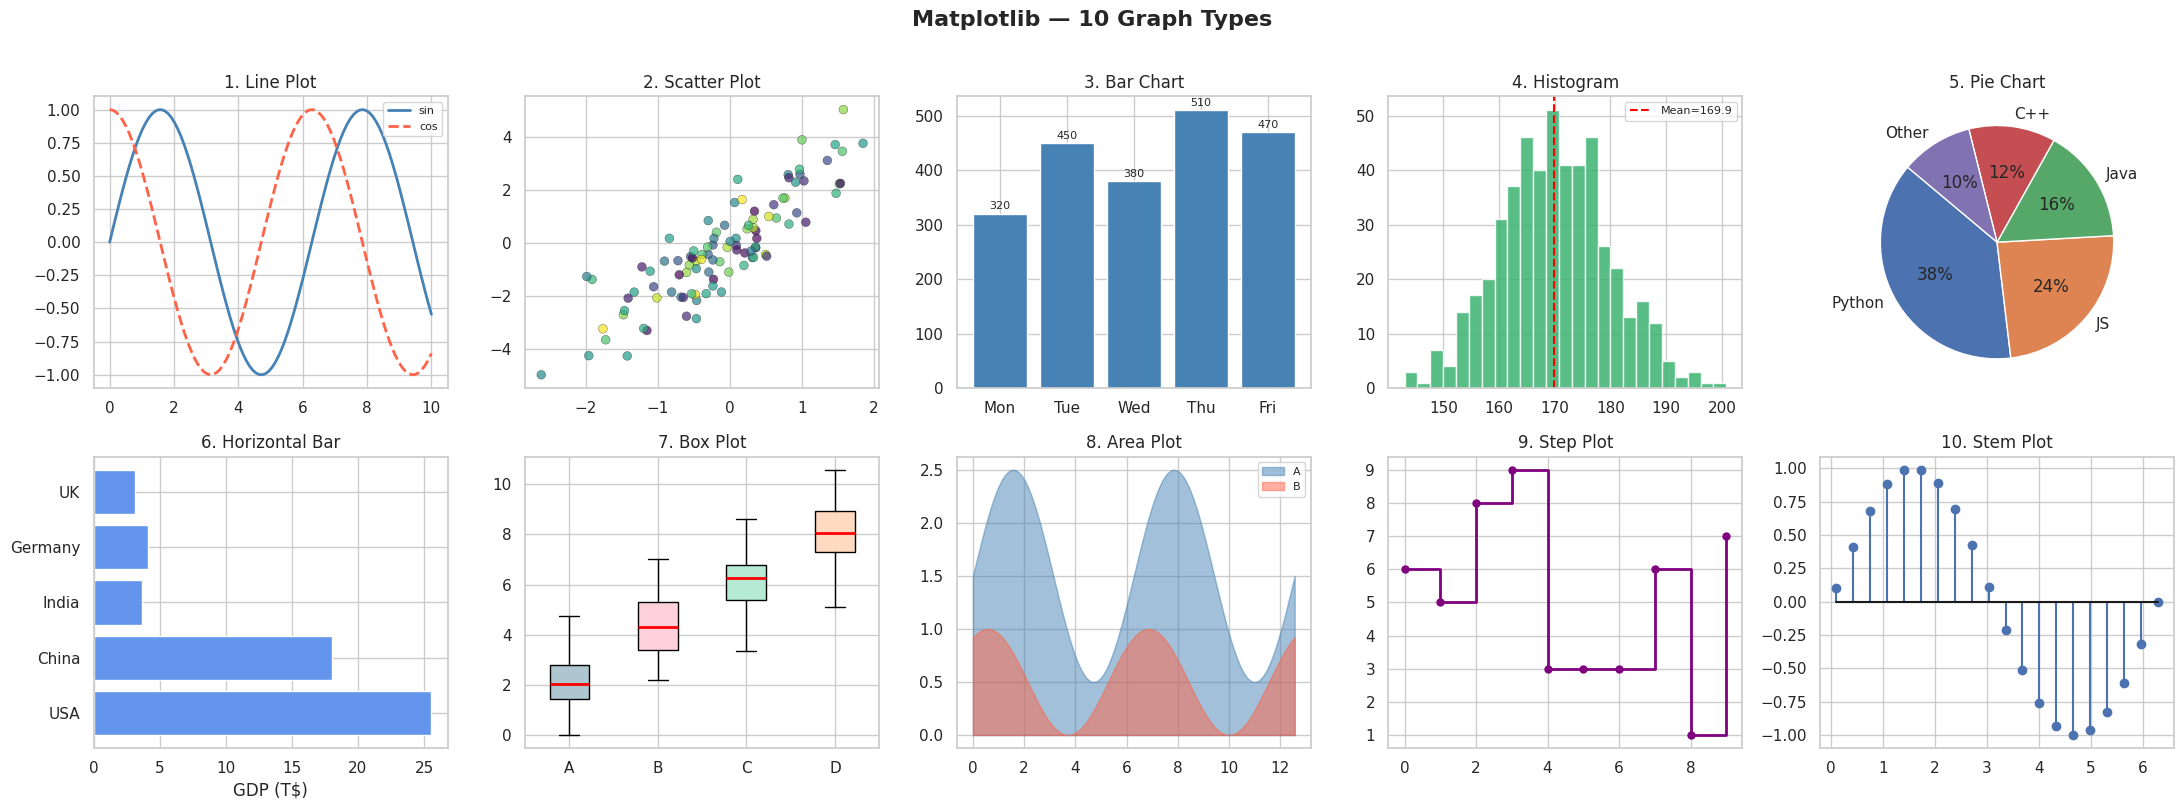

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Matplotlib — 10 Graph Types', fontsize=16, fontweight='bold', y=1.01)

# 1. Line Plot
x = np.linspace(0, 10, 100)
axes[0,0].plot(x, np.sin(x), label='sin', color='steelblue', lw=2)
axes[0,0].plot(x, np.cos(x), label='cos', color='tomato', lw=2, ls='--')
axes[0,0].set_title('1. Line Plot'); axes[0,0].legend(fontsize=8)

# 2. Scatter Plot
np.random.seed(42)
xs = np.random.randn(100); ys = 2*xs + np.random.randn(100)
sc = axes[0,1].scatter(xs, ys, c=np.random.rand(100), cmap='viridis', alpha=0.7, edgecolors='k', lw=0.3, s=40)
axes[0,1].set_title('2. Scatter Plot')

# 3. Bar Chart
cats = ['Mon','Tue','Wed','Thu','Fri']; vals = [320,450,380,510,470]
bars = axes[0,2].bar(cats, vals, color='steelblue', edgecolor='white')
for b,v in zip(bars,vals): axes[0,2].text(b.get_x()+b.get_width()/2, b.get_height()+8, str(v), ha='center', fontsize=8)
axes[0,2].set_title('3. Bar Chart')

# 4. Histogram
data = np.random.normal(170, 10, 500)
axes[0,3].hist(data, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,3].axvline(data.mean(), color='red', ls='--', lw=1.5, label=f'Mean={data.mean():.1f}')
axes[0,3].set_title('4. Histogram'); axes[0,3].legend(fontsize=8)

# 5. Pie Chart
axes[0,4].pie([38,24,16,12,10], labels=['Python','JS','Java','C++','Other'],
              autopct='%1.0f%%', startangle=140,
              colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
axes[0,4].set_title('5. Pie Chart')

# 6. Horizontal Bar
countries = ['USA','China','India','Germany','UK']; gdp=[25.5,18.0,3.7,4.1,3.1]
axes[1,0].barh(countries, gdp, color='cornflowerblue', edgecolor='white')
axes[1,0].set_title('6. Horizontal Bar'); axes[1,0].set_xlabel('GDP (T$)')

# 7. Box Plot
data_box = [np.random.normal(loc, 1.2, 60) for loc in [2,4,6,8]]
bp = axes[1,1].boxplot(data_box, patch_artist=True, medianprops=dict(color='red',lw=2))
for patch,c in zip(bp['boxes'],['#AEC6CF','#FFD1DC','#B5EAD7','#FFDAC1']): patch.set_facecolor(c)
axes[1,1].set_xticks([1,2,3,4]); axes[1,1].set_xticklabels(['A','B','C','D'])
axes[1,1].set_title('7. Box Plot')

# 8. Area / Fill Plot
xa = np.linspace(0, 4*np.pi, 200)
axes[1,2].fill_between(xa, np.sin(xa)+1.5, alpha=0.5, color='steelblue', label='A')
axes[1,2].fill_between(xa, 0.5*np.sin(xa+1)+0.5, alpha=0.5, color='tomato', label='B')
axes[1,2].set_title('8. Area Plot'); axes[1,2].legend(fontsize=8)

# 9. Step Plot
step_x = np.arange(10); step_y = np.random.randint(1,10,10)
axes[1,3].step(step_x, step_y, color='purple', lw=2, where='post')
axes[1,3].plot(step_x, step_y, 'o', color='purple', ms=5)
axes[1,3].set_title('9. Step Plot')

# 10. Stem Plot
xs2 = np.linspace(0.1, 2*np.pi, 20)
axes[1,4].stem(xs2, np.sin(xs2), linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[1,4].set_title('10. Stem Plot')

plt.tight_layout()
plt.show()

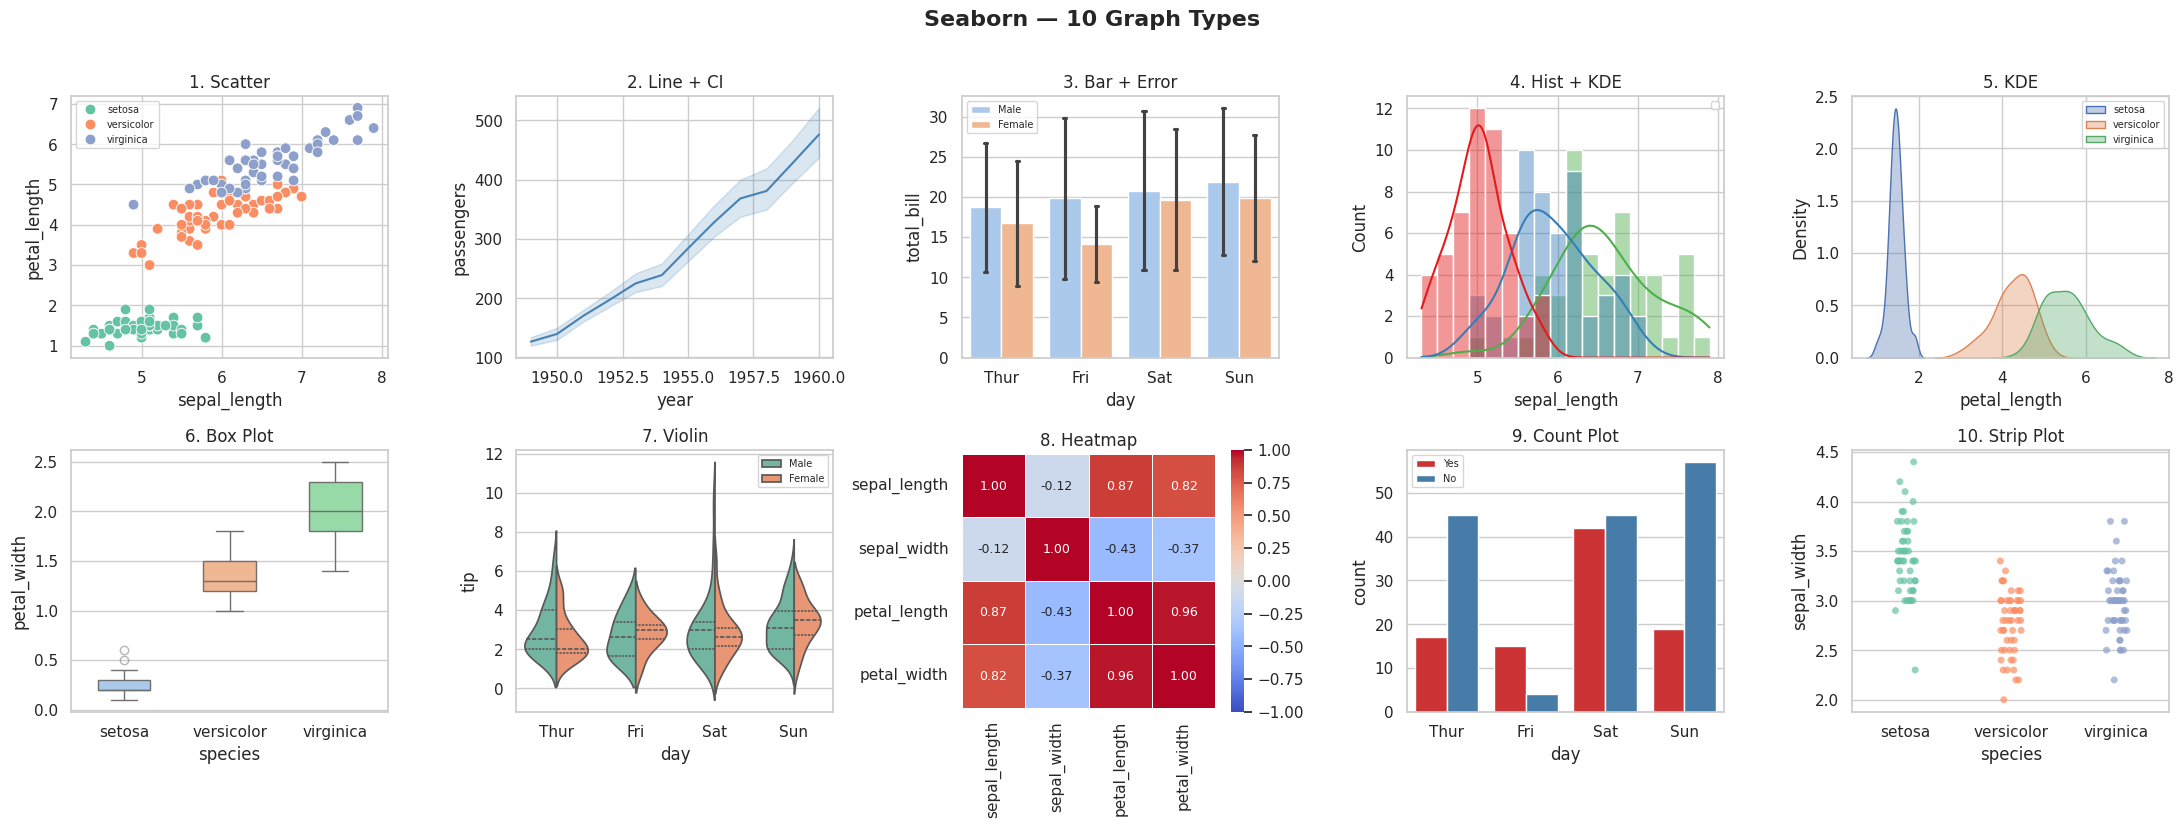

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Seaborn — 10 Graph Types', fontsize=16, fontweight='bold', y=1.01)

# 1. Scatter Plot
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',
                hue='species', palette='Set2', s=60, ax=axes[0,0])
axes[0,0].set_title('1. Scatter'); axes[0,0].legend(fontsize=7)

# 2. Line Plot with CI
sns.lineplot(data=flights, x='year', y='passengers',
             estimator='mean', errorbar='ci', color='steelblue', ax=axes[0,1])
axes[0,1].set_title('2. Line + CI')

# 3. Bar Plot
sns.barplot(data=tips, x='day', y='total_bill', hue='sex',
            palette='pastel', capsize=0.08, errorbar='sd', ax=axes[0,2])
axes[0,2].set_title('3. Bar + Error'); axes[0,2].legend(fontsize=7)

# 4. Histogram + KDE
sns.histplot(data=iris, x='sepal_length', hue='species',
             kde=True, bins=18, palette='Set1', alpha=0.45, ax=axes[0,3])
axes[0,3].set_title('4. Hist + KDE'); axes[0,3].legend(fontsize=7)

# 5. KDE Plot
for sp, grp in iris.groupby('species'):
    sns.kdeplot(grp['petal_length'], fill=True, alpha=0.35, label=sp, ax=axes[0,4])
axes[0,4].set_title('5. KDE'); axes[0,4].legend(fontsize=7)

# 6. Box Plot
sns.boxplot(data=iris, x='species', y='petal_width',
            palette='pastel', width=0.5, ax=axes[1,0],
            flierprops=dict(marker='o', color='red', alpha=0.5))
axes[1,0].set_title('6. Box Plot')

# 7. Violin Plot
sns.violinplot(data=tips, x='day', y='tip', hue='sex',
               split=True, palette='Set2', inner='quart', ax=axes[1,1])
axes[1,1].set_title('7. Violin'); axes[1,1].legend(fontsize=7)

# 8. Heatmap
corr = iris.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1, ax=axes[1,2], annot_kws={'size':9})
axes[1,2].set_title('8. Heatmap')

# 9. Count Plot
sns.countplot(data=tips, x='day', hue='smoker', palette='Set1',
              order=['Thur','Fri','Sat','Sun'], ax=axes[1,3])
axes[1,3].set_title('9. Count Plot'); axes[1,3].legend(fontsize=7)

# 10. Strip Plot
sns.stripplot(data=iris, x='species', y='sepal_width',
              hue='species', palette='Set2', jitter=True,
              dodge=False, alpha=0.7, ax=axes[1,4], legend=False)
axes[1,4].set_title('10. Strip Plot')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

comparison = pd.DataFrame({
    'Criterion'      : ['Ease of use','Customization','Interactivity',
                        'Statistical plots','Large data','Aesthetics','DataFrame support'],
    'Matplotlib'     : ['⭐⭐ (verbose)','⭐⭐⭐⭐⭐ (full control)',
                        '❌ static only','⭐⭐ manual','⭐⭐⭐⭐','⭐⭐ plain','⭐⭐⭐'],
    'Seaborn'        : ['⭐⭐⭐⭐ (concise)','⭐⭐⭐ (theme-based)',
                        '❌ static only','⭐⭐⭐⭐⭐ built-in','⭐⭐⭐','⭐⭐⭐⭐⭐','⭐⭐⭐⭐⭐'],
})
print(comparison.to_string(index=False))
print("\nTip: combine both — sns.boxplot() draws the chart, ax.set_title() fine-tunes it.")

        Criterion           Matplotlib           Seaborn
      Ease of use         ⭐⭐ (verbose)    ⭐⭐⭐⭐ (concise)
    Customization ⭐⭐⭐⭐⭐ (full control) ⭐⭐⭐ (theme-based)
    Interactivity        ❌ static only     ❌ static only
Statistical plots            ⭐⭐ manual    ⭐⭐⭐⭐⭐ built-in
       Large data                 ⭐⭐⭐⭐               ⭐⭐⭐
       Aesthetics             ⭐⭐ plain             ⭐⭐⭐⭐⭐
DataFrame support                  ⭐⭐⭐             ⭐⭐⭐⭐⭐

Tip: combine both — sns.boxplot() draws the chart, ax.set_title() fine-tunes it.
